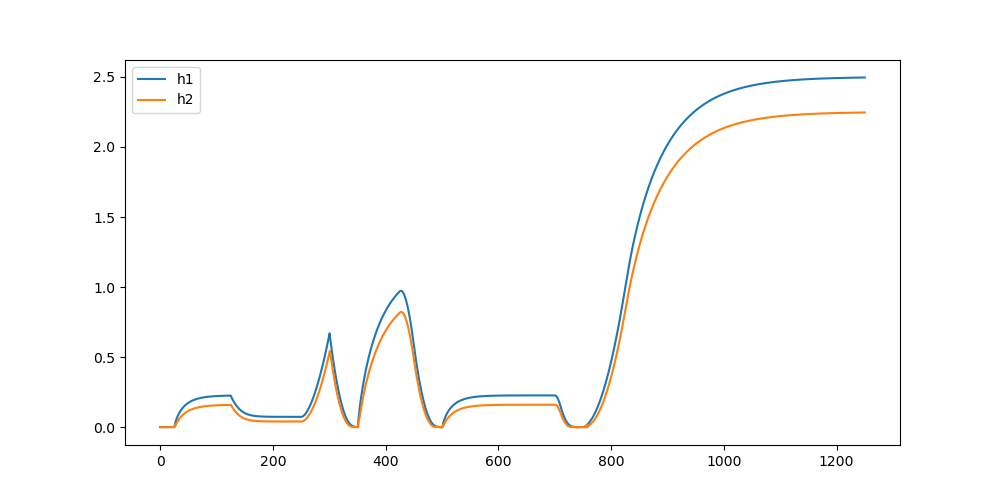

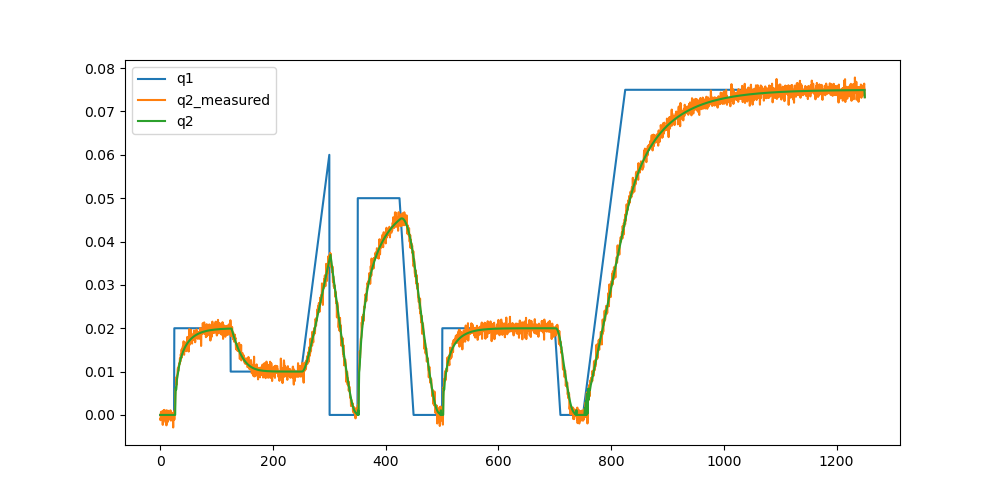

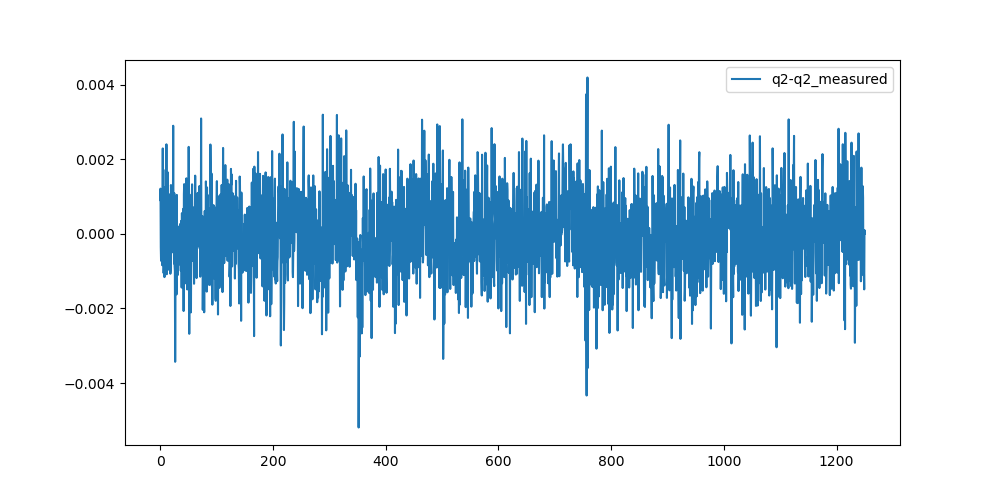

/tmp/ipykernel_38388/3118392867.py:179: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(data.t, [data.k * sqrt(x) for x in data.h2], label="$k\\sqrt{h_2}$")


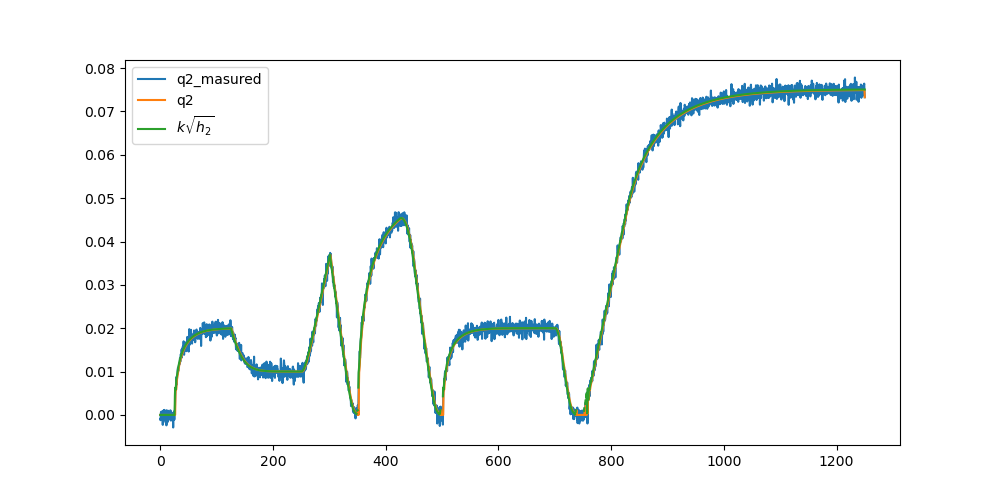

In [1]:
import types
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from numpy import sqrt
import csv
import typing
from collections import namedtuple
from scipy.linalg import solve, inv, pinv
from IPython.display import display, Markdown, Latex



plt.style.use('default')
plt.interactive(True)
plt.rcParams['figure.figsize'] = [10, 5]

DATA_FILE_NAME = "./data_main.csv"

class Sample:
    index:int = 0

    # from data
    t:float = 0
    q1:float = 0,
    h1:float = 0
    h2:float = 0
    q2_measured:float = 0

    # derived
    q2:float = 0
    v1:float = 0 # volume in tank 1
    v2:float = 0 # volume in tank 2
    vt:float = 0 # total volume
    vdif:float = 0
    delta:float = 0 # time delta
    total_inflow:float = 0
    total_outflow:float = 0

    prev:typing.Self = None
    next:typing.Self = None

def SamplesFromFile(filename:str)->list[Sample]:
    samples = []
    with open(DATA_FILE_NAME) as file:
        reader = csv.reader(file, delimiter=";")
        i = 0
        total_inflow = 0.0
        for row in reader:
            break
        for row in reader:
            s = Sample()
            s.index = i
            s.t = np.float64(row[0].replace(",", "."))
            s.q1 = np.float64(row[1].replace(",", "."))
            s.h1 = np.float64(row[2].replace(",", "."))
            s.h2 = np.float64(row[3].replace(",", "."))
            s.q2_measured = np.float64(row[4].replace(",", "."))
            # s.t = np.float64(row["t[sec]"].replace(",", "."))
            # s.q1 = float(row["q1[m3/h]"].replace(",", "."))
            # print(row["q1[m3/h]"])
            # s.h1 = np.float64(row["h1[m]"].replace(",", "."))
            # s.h2 = np.float64(row["h2[m]"].replace(",", "."))
            # s.q2_measured = np.float64(row["q2_measurement[m3/h]"].replace(",", "."))
            if i != 0:
                samples[i-1].next = s
                s.prev = samples[i-1]
                s.delta =  s.t-s.prev.t
                s.total_inflow = total_inflow
            samples.append(s)
            total_inflow += s.q1
            i+=1
    return samples

class Dataset:
    name:str = ""

    n:int = 0

    samples:list[Sample] = []

    # for convenience
    t:npt.ArrayLike = []
    h1:npt.ArrayLike = []
    h2:npt.ArrayLike = []
    v1:npt.ArrayLike = []
    v2:npt.ArrayLike = []
    q1:npt.ArrayLike = []
    q2:npt.ArrayLike = []
    q2_measured:npt.ArrayLike = []

    total_time:float = 0
    S1:float = 0
    S2:float = 0
    a:float = 0
    k:float = 0
    inflow_start_index:int = 0

    total_inflow:float = 0
    total_outflow:float = 0

    k_points:list[float] = []
    a_points:list[float] = []

    def __init__(self, filename:str):
        samples = SamplesFromFile(filename)
        i = 0
        while samples[i].q1 == 0:
            i += 1
        s = samples[i]
        self.inflow_start_index = i
        self.S1 = s.q1 / s.next.h1

        ft2 = (samples[i].q1+samples[i+1].q1)
        self.S2 = (ft2 - self.S1*samples[i+2].h1) / samples[i+2].h2

        for s in samples:
            s.v1 = self.S1 * s.h1
            s.v2 = self.S2 * s.h2
            s.vt = s.v1 + s.v2
            if s.prev is not None:
                vexp = s.prev.vt + s.prev.q1
                s.vdif = s.vt-s.prev.vt
                s.q2 = (vexp-s.vt)
                self.total_outflow += s.q2
                s.total_outflow = self.total_outflow
                if s.prev.h2 > 0:
                    self.k_points.append(s.q2/sqrt(s.prev.h2))

        samples[-1].q2 = samples[-1].q2_measured
        samples[-1].vt = samples[-2].vt
        samples[-1].v1 = samples[-2].v1
        samples[-1].v2 = samples[-2].v2

        self.a = samples[self.inflow_start_index+2].v2 / samples[self.inflow_start_index+1].h1
        #self.k = samples[self.inflow_start_index+3].q2 / sqrt(samples[self.inflow_start_index+2].h2)
        self.k = np.mean(self.k_points)

        # Stupidly unoptimized, but shouldn't matter
        self.t = np.array([s.t for s in samples])
        self.h1 = np.array([s.h1 for s in samples])
        self.h2 = np.array([s.h2 for s in samples])
        self.v1 = np.array([s.v1 for s in samples])
        self.v2 = np.array([s.v2 for s in samples])
        self.q1 = np.array([s.q1 for s in samples])
        self.q2_measured = np.array([s.q2_measured for s in samples])
        self.q2 = np.array([s.q2 for s in samples])
        self.n = len(samples)
        self.samples = samples
        self.total_time = samples[-1].t
        self.total_inflow = samples[-1].total_inflow


data = Dataset(DATA_FILE_NAME)

fig = plt.figure()
plt.plot(data.t, data.h1, label="h1")
plt.plot(data.t, data.h2, label="h2")
plt.legend()
plt.show()
fig = plt.figure()
plt.plot(data.t, data.q1, label="q1")
plt.plot(data.t, data.q2_measured, label="q2_measured")
plt.plot(data.t, data.q2, label="q2")
plt.interactive(True)
plt.legend()
plt.show()

fig = plt.figure()
plt.plot(data.t, data.q2-data.q2_measured, label="q2-q2_measured")
plt.legend()
plt.show()

fig = plt.figure()
plt.plot(data.t, data.q2_measured, label="q2_masured")
plt.plot(data.t, data.q2, label="q2")
plt.plot(data.t, [data.k * sqrt(x) for x in data.h2], label="$k\\sqrt{h_2}$")
plt.legend()
plt.show()

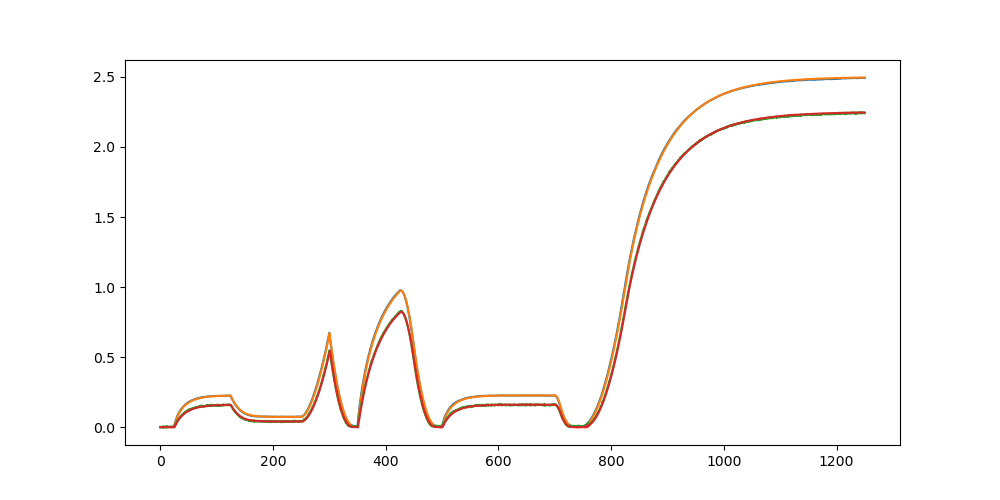

In [6]:
import filterpy
from filterpy.common import Q_discrete_white_noise

class KalmanOutput:
    h1 = []
    h2 = []
    q1 = []
    q2 = []
    predictions = []

def KalmanStepEx1(q1, q2, V, P, R, H, Q, a, k, S1, S2):

    F = np.array([[(1 - a/S1), a/S1 , 0],
              [a/S2, (1 - a/S2), -(1 / S2)],
              [0, k*((1/sqrt(V[1, 0])) if V[1, 0] > 0.01 else 0), 0]])

    Bu = np.array([[q1/S1], [0], [0]])
    P = F @ P @ F.T + Q
    pred = F @ V + Bu
    S = H @ P @ H.T + R
    z = np.array([[q2]])
    y = z - H @ pred
    K = P @ H.T @ pinv(S)
    x = pred + (K @ y)
    P = P - K @ H @ P
    return x, P, pred
def KalmanEx1(inputs, readings, V, P, R, H, Qfv:npt.ArrayLike|types.FunctionType, k, a, S1, S2)->KalmanOutput:
    output = KalmanOutput()
    i = 0
    while readings[i] == 0:
        output.q1.append(0)
        output.q2.append(0)
        output.h1.append(0)
        output.h1.append(0)
        output.p1.append(np.array([[0],[0],[0]]))
        i += 1
    while i < len(readings):
        q1 = inputs[i]
        q2 = readings[i]
        Q = Qfv(V, P) if type(Qfv) == types.FunctionType else Qfv
        V, P, pred = KalmanStepEx1(q1, q2, V, P, R, H, Q, a, k, S1, S2)

        output.q1.append(q1)
        output.h1.append(V[0, 0])
        output.h2.append(V[1, 0])
        output.q2.append(V[2, 0])
        output.predictions.append(pred)

        i += 1
    return output

step = data.t[1]-data.t[0]
V = np.array([[0],
             [0],
             [0]])
P = np.diag([1, 1, 1])
R = np.array([[0.01]])
H = np.array([[0, 0, 1]])
Q = lambda V, P: Q_discrete_white_noise(dim=3, dt=step, var=3)

results = KalmanEx1(data.q1, data.q2_measured, V, P, R, H, Q, data.k, data.a, data.S1, data.S2)

fig = plt.figure()

plt.plot(data.t, results.h1, label="h1 estimate")
plt.plot(data.t, data.h1, label="h1 real")
plt.plot(data.t, results.h2, label="h2 estimate")
plt.plot(data.t, data.h2, label="h2 real")

plt.show()